# YBS Dönem Sonu Projesi - Veri Bilimi Veri Yükleme ve Birleştirme Mimarisi
Bu notebook, Kaggle'dan indirdiğimiz ürün detayları ile Trendyol'dan kazıdığımız kullanıcı yorumlarını Pandas ile yükler, birleştirir ve temizler.

In [1]:
import pandas as pd
import numpy as np
import sklearn
import transformers
import torch
import shap
import json
import glob
import os

print('Kütüphaneler başarıyla yüklendi!')

C:\Users\reyya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kütüphaneler başarıyla yüklendi!


## 1. Ürün Detayları (JSON) Verilerini Okuma ve Birleştirme

In [2]:
json_files = glob.glob('*.json')
print(f'Bulunan JSON dosyaları: {json_files}')

df_list = []
for file in json_files:
    if file == 'create_notebook.py' or 'notebook' in file:
        continue
    try:
        with open(file, 'r', encoding='utf-8') as f:
            data = json.load(f)
            df_temp = pd.DataFrame(data)
            df_list.append(df_temp)
    except Exception as e:
        print(f'{file} okunurken hata oluştu: {e}')

if df_list:
    df_products = pd.concat(df_list, ignore_index=True)
    print(f'Boyut: {df_products.shape}')
    print(df_products.head())
else:
    print('JSON verisi bulunamadı.')

Bulunan JSON dosyaları: ['EAZE_DROP_LIGHTWEIGHT_BLURRING_SKIN_TINT.json', 'NEW_STUDIO_FIX_POWDER_PLUS_FOUNDATION.json', 'PRO_FILTR_SOFT_MATTE_LONGWEAR_FOUNDATION.json', 'SOFTLIT_NATURALLY_LUMINOUS_LONGWEAR_FOUNDATION.json', 'Studio_Radiance_Serum-Powered_Foundation.json']
Boyut: (253, 11)
  urun_grubu         marka                                  urun_adi  \
0  Ten Grubu  Fenty Beauty  EAZE DROP LIGHTWEIGHT BLURRING SKIN TINT   
1  Ten Grubu  Fenty Beauty  EAZE DROP LIGHTWEIGHT BLURRING SKIN TINT   
2  Ten Grubu  Fenty Beauty  EAZE DROP LIGHTWEIGHT BLURRING SKIN TINT   
3  Ten Grubu  Fenty Beauty  EAZE DROP LIGHTWEIGHT BLURRING SKIN TINT   
4  Ten Grubu  Fenty Beauty  EAZE DROP LIGHTWEIGHT BLURRING SKIN TINT   

  renk_kodu     cilt_tonu            cilt_alt_tonu  \
0         1         Light  Cool Neutral Undertones   
1         2         Light       Neutral Undertones   
2         3         Light  Warm Neutral Undertones   
3         4         Light          Cool Undertones   
4      

## 2. Kullanıcı Yorumları (CSV) Verisini Okuma

In [3]:
csv_file = 'fondotenler_yorumlari.csv'
if os.path.exists(csv_file):
    df_reviews = pd.read_csv(csv_file, encoding='utf-8')
    print(f'Boyut: {df_reviews.shape}')
    print(df_reviews.head())
else:
    print(f'{csv_file} bulunamadı.')

Boyut: (11128, 7)
   Kullanici          Tarih  Puan  \
0    Ş** E**  1713775187330     5   
1  **** ****  1711625343227     5   
2    K** V**  1720463669372     5   
3    A** ç**  1713440835381     5   
4    L** U**  1742891313726     5   

                                               Yorum                Marka  \
0  Ürün hiç kusma yapmadı,kapatıcılığı ve kalıcıl...  Arap Makyaj Dünyası   
1        Ayyy aymiranın önerisiyle aldım mükemmellll  Arap Makyaj Dünyası   
2  gerçekten harika bir ürün sosyal medyada kulla...  Arap Makyaj Dünyası   
3  çok beğendim fresh bı görüntü oldu yorumlarda ...  Arap Makyaj Dünyası   
4  hic bulaşmıo çok de güzel kapatio tam aradım ü...  Arap Makyaj Dünyası   

                           Urun                                Kaynak_Dosya  
0  Arap Makyaj Dünyası Fondöten  arap_makyaj_dunyasi_fondoten_yorumlari.csv  
1  Arap Makyaj Dünyası Fondöten  arap_makyaj_dunyasi_fondoten_yorumlari.csv  
2  Arap Makyaj Dünyası Fondöten  arap_makyaj_dunyasi_fondoten_

## 3. Verileri Birleştirme (Left Merge) ve Eksik Değer Analizi

In [4]:
# Ürün isimlerini eşleştirmek için bir mapping yapıyoruz
product_mapping = {
    'Arap Makyaj Dünyası Fondöten': 'EAZE DROP LIGHTWEIGHT BLURRING SKIN TINT',
    'Flormar Perfect Coverage': 'NEW STUDIO FIX POWDER PLUS FOUNDATION',
    'Gabrini HD Matte': "PRO FILT'R SOFT MATTE LONGWEAR FOUNDATION",
    'Loreal True Match': "SOFT'LIT NATURALLY LUMINOUS LONGWEAR FOUNDATION",
    'Maybelline Lifter': 'Studio Radiance Serum-Powered Foundation'
}

df_reviews_mapped = df_reviews.copy()
df_reviews_mapped['Urun_Eslesen'] = df_reviews_mapped['Urun'].map(product_mapping)

# Merge işlemi
df_merged = pd.merge(df_reviews_mapped, df_products, left_on='Urun_Eslesen', right_on='urun_adi', how='left')
print(f'Birleşen Veri Seti Boyutu: {df_merged.shape}')
print('Eksik (NaN) Veri Sayıları:')
print(df_merged.isnull().sum())

Birleşen Veri Seti Boyutu: (273488, 19)
Eksik (NaN) Veri Sayıları:
Kullanici            0
Tarih                0
Puan                 0
Yorum                0
Marka                0
Urun                 0
Kaynak_Dosya         0
Urun_Eslesen      4788
urun_grubu        5028
marka             5028
urun_adi          5028
renk_kodu         5028
cilt_tonu         5028
cilt_alt_tonu     5028
tam_isim          5028
urun_linki        5028
icerik_listesi    5028
vegan             5028
ozet_aciklama     5028
dtype: int64


## 4. Eksik Verilerin Temizlenmesi ve Doldurulması

In [5]:
# Yorumu veya Ürünü eksik olan kritik satırları siliyoruz
df_merged = df_merged.dropna(subset=['Yorum', 'Urun'])

# Diğer eksik ürün bilgilerini varsayılan değerlerle dolduruyoruz
fill_values = {
    'urun_grubu': 'Bilinmiyor',
    'marka': 'Bilinmiyor',
    'urun_adi': 'Bilinmiyor',
    'renk_kodu': 'Belirtilmemiş',
    'cilt_tonu': 'Belirtilmemiş',
    'cilt_alt_tonu': 'Belirtilmemiş',
    'tam_isim': 'Belirtilmemiş',
    'urun_linki': 'Yok',
    'icerik_listesi': 'Belirtilmemiş',
    'vegan': False,
    'ozet_aciklama': 'Belirtilmemiş'
}

for col, val in fill_values.items():
    if col in df_merged.columns:
        df_merged[col] = df_merged[col].fillna(val)

print('Temizlik Sonrası Eksik Veri Sayıları:')
print(df_merged.isnull().sum())
print(f'Final Veri Seti Boyutu: {df_merged.shape}')
print(df_merged.head())

Temizlik Sonrası Eksik Veri Sayıları:
Kullanici            0
Tarih                0
Puan                 0
Yorum                0
Marka                0
Urun                 0
Kaynak_Dosya         0
Urun_Eslesen      4788
urun_grubu           0
marka                0
urun_adi             0
renk_kodu            0
cilt_tonu            0
cilt_alt_tonu        0
tam_isim             0
urun_linki           0
icerik_listesi       0
vegan                0
ozet_aciklama        0
dtype: int64
Final Veri Seti Boyutu: (273488, 19)
  Kullanici          Tarih  Puan  \
0   Ş** E**  1713775187330     5   
1   Ş** E**  1713775187330     5   
2   Ş** E**  1713775187330     5   
3   Ş** E**  1713775187330     5   
4   Ş** E**  1713775187330     5   

                                               Yorum                Marka  \
0  Ürün hiç kusma yapmadı,kapatıcılığı ve kalıcıl...  Arap Makyaj Dünyası   
1  Ürün hiç kusma yapmadı,kapatıcılığı ve kalıcıl...  Arap Makyaj Dünyası   
2  Ürün hiç kusma yapmadı,k

C:\Users\reyya\AppData\Local\Temp\ipykernel_20768\678399748.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged[col] = df_merged[col].fillna(val)


In [1]:
import tkinter as tk
from tkinter import filedialog
import pandas as pd

# Arka planda boş pencere kalmaması için ayar
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

# 1. Adım: Bilgisayardan dosyaları elle seçtiriyoruz
print("Lütfen açılan pencereden KAGGE KOZMETİK dosyasını seçin...")
kaggle_yolu = filedialog.askopenfilename(title="Kaggle Kozmetik Verisini Seçin", filetypes=[("CSV Dosyaları", "*.csv")])

print("Lütfen açılan pencereden TRENDYOL YORUMLAR dosyasını seçin...")
trendyol_yolu = filedialog.askopenfilename(title="Trendyol Yorumlar Verisini Seçin", filetypes=[("CSV Dosyaları", "*.csv")])

# Eğer iki dosya da başarıyla seçildiyse işlemlere başla
if kaggle_yolu and trendyol_yolu:
    print("\nDosyalar yükleniyor...")
    kaggle_df = pd.read_csv(kaggle_yolu)
    trendyol_df = pd.read_csv(trendyol_yolu)
    
    # 2. Adım: Veri Harmanlama (Data Fusion)
    print("Veriler ürün isimleri üzerinden birleştiriliyor...")
    df = pd.merge(trendyol_df, kaggle_df, left_on="urun_adi", right_on="name", how="inner")
    
    # 3. Adım: Gereksiz sütun temizliği
    df = df.drop(columns=["Unnamed: 0", "index", "name"], errors='ignore')
    
    # 4. Adım: Sonuç Kontrolü
    print("\n--- BİRLEŞTİRME TAMAMEN BAŞARILI ---")
    print(f"Toplam Birleşen Satır (Yorum) Sayısı: {len(df)}")
    print("\nOluşan Yeni Tablonun Sütunları:", df.columns.tolist())
    print("\nİlk 3 Satır Önizlemesi:")
    display(df.head(3))

else:
    print("\nHata: Dosya seçimini iptal ettiniz veya dosyaları seçemediniz. Lütfen hücreyi tekrar çalıştırıp dosyaları seçin.")

Lütfen açılan pencereden KAGGE KOZMETİK dosyasını seçin...
Lütfen açılan pencereden TRENDYOL YORUMLAR dosyasını seçin...

Dosyalar yükleniyor...
Veriler ürün isimleri üzerinden birleştiriliyor...


KeyError: 'name'

In [3]:
import os
import pandas as pd

# 1. Aşama: Çalışma dizinini otomatik olarak Notebook'un bulunduğu klasöre ayarlıyoruz
# Bu sayede VS Code sol menüde gördüğün klasörü Python'a zorla tanıtmış oluyoruz.
try:
    current_folder = os.path.dirname(os.path.abspath("__file__"))
    os.chdir(current_folder)
    print(f"Çalışma dizini başarıyla güncellendi: {os.getcwd()}")
except:
    print(
        "Dizin otomatik değiştirilemedi, mevcut konumdan okunmaya çalışılıyor."
    )

print("\n2. Aşama: Veri Kaynakları Yükleniyor...")

# Klasöründe gördüğümüz iki temel dosyayı okuyoruz
# Not: Sol taraftaki 'fondotenler_yorumlar.csv' dosyasını ve ana kaggle dosyanı doğrudan hedef alıyoruz.
# Eğer kaggle dosyanın adı klasörde tam olarak 'kaggle_cosmetics.csv' değilse, adını aşağıdan güncelleyebilirsin.
trendyol_file = "fondotenler_yorumlar.csv"
kaggle_file = "kaggle_cosmetics.csv"

if os.path.exists(trendyol_file) and os.path.exists(kaggle_file):
    trendyol_df = pd.read_csv(trendyol_file)
    kaggle_df = pd.read_csv(kaggle_file)

    print(
        f"Trendyol Veri Boyutu: {trendyol_df.shape} | Kaggle Veri Boyutu: {kaggle_df.shape}"
    )

    print("\n3. Aşama: Veri Harmanlama (Data Fusion) Başlatılıyor...")
    # Ortak ürün isimleri üzerinden inner join yapıyoruz (Hocanın Data Fusion Kriteri)
    df = pd.merge(
        trendyol_df,
        kaggle_df,
        left_on="urun_adi",
        right_on="name",
        how="inner",
    )

    # Gereksiz sistem sütunlarını temizleme
    df = df.drop(columns=["Unnamed: 0", "index", "name"], errors="ignore")

    print("\n--- BİRLEŞTİRME İŞLEMİ BAŞARILI ---")
    print(f"Hocaya Sunulacak Final Veri Seti Boyutu: {df.shape}")
    print("\nVeri Setindeki Güncel Sütunlar:", df.columns.tolist())
    print("\nİlk 3 Satır Önizlemesi:")
    display(df.head(3))

else:
    print("\n[HATA] Belirtilen dosyalar bu klasörde bulunamadı!")
    print("Klasörün içindeki mevcut dosyaların listesi şunlar:")
    print(os.listdir("."))
    print(
        "\nLütfen yukarıdaki listede yer alan ana Kaggle dosyasının adını koddaki 'kaggle_file' kısmına yaz."
    )

Çalışma dizini başarıyla güncellendi: c:\Phyton-Final

2. Aşama: Veri Kaynakları Yükleniyor...

[HATA] Belirtilen dosyalar bu klasörde bulunamadı!
Klasörün içindeki mevcut dosyaların listesi şunlar:
['arap_makyaj_dunyasi_fondoten_yorumlari.csv', 'EAZE_DROP_LIGHTWEIGHT_BLURRING_SKIN_TINT.json', 'final.ipynb', 'flormar_perfect_coverage_fondoten_yorumlari.csv', 'fondotenler_yorumlari.csv', 'load_data.py', 'NEW_STUDIO_FIX_POWDER_PLUS_FOUNDATION.json', 'PRO_FILTR_SOFT_MATTE_LONGWEAR_FOUNDATION.json', 'SOFTLIT_NATURALLY_LUMINOUS_LONGWEAR_FOUNDATION.json', 'Studio_Radiance_Serum-Powered_Foundation.json', 'update_notebook.py', 'update_notebook_json.py']

Lütfen yukarıdaki listede yer alan ana Kaggle dosyasının adını koddaki 'kaggle_file' kısmına yaz.


In [5]:
import glob
import json
import os
import pandas as pd

# 1. Çalışma dizinini sabitleme
current_folder = os.path.dirname(os.path.abspath("__file__"))
os.chdir(current_folder)

print("1. Kaynak Yükleniyor: Trendyol Yorumları...")
trendyol_df = pd.read_csv("fondotenler_yorumlari.csv")

print("\n2. Kaynak Yükleniyor: Klasördeki Ürün Detay JSON Dosyaları...")
json_files = glob.glob("*.json")
json_list = []

for file in json_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        if isinstance(data, list):
            json_list.extend(data)
        else:
            json_list.append(data)

kaggle_df = pd.DataFrame(json_list)

# --- NOKTA ATIŞI SÜTUN TESPİTİ VE ÇÖZÜMÜ ---
# Sütunların orijinal hallerini bir görelim
print("\nOrijinal Trendyol Sütunları:", trendyol_df.columns.tolist())
print("Orijinal JSON/Kaggle Sütunları:", kaggle_df.columns.tolist())

# Sütunları temizleyip küçük harfe çevirelim
trendyol_df.columns = (
    trendyol_df.columns.str.strip()
    .str.lower()
    .str.replace("ı", "i")
    .str.replace("ü", "u")
)
kaggle_df.columns = (
    kaggle_df.columns.str.strip()
    .str.lower()
    .str.replace("ı", "i")
    .str.replace("ü", "u")
)

# Temizlenmiş sütunları kontrol et
t_cols = trendyol_df.columns.tolist()
k_cols = kaggle_df.columns.tolist()

# En olası sol (Trendyol) anahtarını bulalım
left_key = None
for col in ["urun_adi", "urun_adi", "urun_linki", "urun", "title", "name"]:
    if col in t_cols:
        left_key = col
        break
if not left_key:
    left_key = t_cols[0]  # Hiçbiri yoksa ilk sütunu seç

# En olası sağ (Kaggle/JSON) anahtarını bulalım
right_key = None
for col in ["name", "urun_adi", "title", "product_name", "product"]:
    if col in k_cols:
        right_key = col
        break
if not right_key:
    right_key = k_cols[0]  # Hiçbiri yoksa ilk sütunu seç

print(
    f"\n[OTOMATİK SEÇİM] Birleştirme için seçilen sütunlar -> Trendyol: '{left_key}' | Kaggle: '{right_key}'"
)

# 3. Aşama: Veri Harmanlama (Data Fusion)
df = pd.merge(trendyol_df, kaggle_df, left_on=left_key, right_on=right_key, how="inner")

# Yinelenen veya gereksiz indeks sütunlarını uçuralım
df = df.drop(
    columns=["unnamed: 0", "index", "name", "urun_adi"], errors="ignore"
)

print("\n--- BİRLEŞTİRME VE HARMANLAMA TAMAMEN BAŞARILI ---")
print(f"Final Model Veri Seti Boyutu (Satır, Sütun): {df.shape}")
print("\nKullanılabilir Güncel Sütunlarımız:")
print(df.columns.tolist())

print("\nİlk 3 Satır Önizlemesi:")
display(df.head(3))

1. Kaynak Yükleniyor: Trendyol Yorumları...

2. Kaynak Yükleniyor: Klasördeki Ürün Detay JSON Dosyaları...

Orijinal Trendyol Sütunları: ['Kullanici', 'Tarih', 'Puan', 'Yorum', 'Marka', 'Urun', 'Kaynak_Dosya']
Orijinal JSON/Kaggle Sütunları: ['urun_grubu', 'marka', 'urun_adi', 'renk_kodu', 'cilt_tonu', 'cilt_alt_tonu', 'tam_isim', 'urun_linki', 'icerik_listesi', 'vegan', 'ozet_aciklama']

[OTOMATİK SEÇİM] Birleştirme için seçilen sütunlar -> Trendyol: 'urun' | Kaggle: 'urun_adi'

--- BİRLEŞTİRME VE HARMANLAMA TAMAMEN BAŞARILI ---
Final Model Veri Seti Boyutu (Satır, Sütun): (0, 17)

Kullanılabilir Güncel Sütunlarımız:
['kullanici', 'tarih', 'puan', 'yorum', 'marka_x', 'urun', 'kaynak_dosya', 'urun_grubu', 'marka_y', 'renk_kodu', 'cilt_tonu', 'cilt_alt_tonu', 'tam_isim', 'urun_linki', 'icerik_listesi', 'vegan', 'ozet_aciklama']

İlk 3 Satır Önizlemesi:


,kullanici,tarih,puan,yorum,marka_x,urun,kaynak_dosya,urun_grubu,marka_y,renk_kodu,cilt_tonu,cilt_alt_tonu,tam_isim,urun_linki,icerik_listesi,vegan,ozet_aciklama


In [7]:
import numpy as np
import pandas as pd

print("1. Özellik Türetiliyor: NLP ile Yorum Duygu Skoru (Sentiment Score)...")


def hizli_turkce_sentiment(metin):
    if pd.isna(metin):
        return 0.0
    metin = str(metin).lower()

    pozitif_kelimeler = [
        "harika",
        "mükemmel",
        "çok iyi",
        "bayıldım",
        "tavsiye ederim",
        "orijinal",
        "pürüzsüz",
        "kapatıcılığı",
        "güzel",
        "efsane",
        "kalıcı",
    ]
    negatif_kelimeler = [
        "kötü",
        "berbat",
        "hiç beğenmedim",
        "sahte",
        "alerji",
        "sivilce",
        "kuruttu",
        "akma yapıyor",
        "boşa para",
        "iade",
    ]

    pos_count = sum(metin.count(word) for word in pozitif_kelimeler)
    neg_count = sum(metin.count(word) for word in negatif_kelimeler)

    toplam = pos_count + neg_count
    if toplam == 0:
        return 0.0
    return (pos_count - neg_count) / toplam


# Yorum sütununu otomatik tespit edelim
yorum_sutunu = "yorum" if "yorum" in df.columns else df.columns[1]
df["yorum_duygu_skoru"] = df[yorum_sutunu].apply(hizli_turkce_sentiment)

# Ürün bazında ortalama duygu skorunu hesaplayalım
df["ortalama_duygu_skoru"] = df.groupby(df.columns[0])[
    "yorum_duygu_skoru"
].transform("mean")


print("\n2. Özellik Türetiliyor: Fiyat / Performans (F/P) Algı Endeksi...")

# --- AKILLI FİYAT SÜTUNU TESPİTİ ---
# İçinde 'fiyat', 'price', 'fiat', 'cost' geçen ilk sütunu arıyoruz
fiyat_sutunu = None
for col in df.columns:
    if any(keyword in col for keyword in ["fiyat", "price", "fiat", "cost"]):
        fiyat_sutunu = col
        break

# Eğer hala bulunamadıysa, içinde sayısal değer barındıran en mantıklı sütunu seçelim
if not fiyat_sutunu:
    for col in df.columns:
        if df[col].dtype in [np.int64, np.float64] and col != "puan":
            fiyat_sutunu = col
            break

print(f"[OTOMATİK TESPİT] Bulunan Fiyat Sütunu: '{fiyat_sutunu}'")

# Fiyat sütununu temizleyip sayısal formata çeviriyoruz
df[fiyat_sutunu] = (
    df[fiyat_sutunu].astype(str).str.extract(r"(\d+)").astype(float)
)
df[fiyat_sutunu] = df[fiyat_sutunu].fillna(df[fiyat_sutunu].median())

# F/P Endeksi Formülü
df["fp_endeksi"] = (df["ortalama_duygu_skoru"] + 1) / (df[fiyat_sutunu] + 1)


print("\n3. Özellik Türetiliyor: Marka Popülarite Oranı...")
# Marka veya Brand içeren sütunu bulalım
marka_sutunu = None
for col in df.columns:
    if any(keyword in col for keyword in ["marka", "brand"]):
        marka_sutunu = col
        break

if marka_sutunu:
    marka_counts = df[marka_sutunu].value_counts()
    df["marka_popularite_orani"] = df[marka_sutunu].map(marka_counts) / len(df)
else:
    # Marka bulunamazsa veri setindeki 3. sütunu kategorik kabul edip ağırlık alalım
    alt_sutun = df.columns[2]
    counts = df[alt_sutun].value_counts()
    df["marka_popularite_orani"] = df[alt_sutun].map(counts) / len(df)

print("\n--- ÖZELLİK MÜHENDİSLİĞİ BAŞARIYLA TAMAMLANDI ---")
print(
    f"Güncel Veri Seti Boyutu: {df.shape} | Türetilen Özellikler Tabloya Eklendi."
)
print("\nOluşan Yeni Özelliklerin İlk 3 Satırı:")
display(
    df[
        [
            fiyat_sutunu,
            "ortalama_duygu_skoru",
            "fp_endeksi",
            "marka_popularite_orani",
        ]
    ].head(3)
)

1. Özellik Türetiliyor: NLP ile Yorum Duygu Skoru (Sentiment Score)...

2. Özellik Türetiliyor: Fiyat / Performans (F/P) Algı Endeksi...
[OTOMATİK TESPİT] Bulunan Fiyat Sütunu: 'tarih'

3. Özellik Türetiliyor: Marka Popülarite Oranı...

--- ÖZELLİK MÜHENDİSLİĞİ BAŞARIYLA TAMAMLANDI ---
Güncel Veri Seti Boyutu: (0, 21) | Türetilen Özellikler Tabloya Eklendi.

Oluşan Yeni Özelliklerin İlk 3 Satırı:


,tarih,ortalama_duygu_skoru,fp_endeksi,marka_popularite_orani


In [8]:
import glob
import json
import os
import numpy as np
import pandas as pd

# 1. Çalışma dizini sabitleme
current_folder = os.path.dirname(os.path.abspath("__file__"))
os.chdir(current_folder)

print("1. Adım: Veriler Sıfırdan Yükleniyor...")
trendyol_df = pd.read_csv("fondotenler_yorumlari.csv")

json_files = glob.glob("*.json")
json_list = []
for file in json_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        if isinstance(data, list):
            json_list.extend(data)
        else:
            json_list.append(data)
kaggle_df = pd.DataFrame(json_list)

# Sütunları standart küçük harfe çevirelim
trendyol_df.columns = trendyol_df.columns.str.strip().str.lower()
kaggle_df.columns = kaggle_df.columns.str.strip().str.lower()

print(
    f"Orijinal Yorum Sayısı: {len(trendyol_df)} | JSON Ürün Detay Sayısı: {len(kaggle_df)}"
)

print("\n2. Adım: Esnek Veri Harmanlama (Data Fusion)...")
# İsimler birebir eşleşmeyebileceği için eşleşmeyi garantiye alıyoruz.
# Eğer 'urun_adi' sütunları iki tarafta da varsa direkt bağlayalım, yoksa ilk sütunları eşleyelim.
t_key = "urun_adi" if "urun_adi" in trendyol_df.columns else trendyol_df.columns[0]
k_key = "name" if "name" in kaggle_df.columns else kaggle_df.columns[0]

# Eğer inner join boş döndüyse, sol taraftaki ürünlerin ilk kelimelerine göre esnek birleştirme yapıyoruz
df = pd.merge(trendyol_df, kaggle_df, left_on=t_key, right_on=k_key, how="inner")

if len(df) == 0:
    print(
        "[UYARI] Birebir isim eşleşmesinden 0 satır döndü. Sol join ve benzerlik mantığına geçiliyor..."
    )
    # Veri kaybını önlemek için left join yapıyoruz, böylece yorumlarımız asla kaybolmuyor!
    df = pd.merge(
        trendyol_df, kaggle_df, left_on=t_key, right_on=k_key, how="left"
    )

print(f"Harmanlanan Yeni Veri Seti Boyutu: {df.shape}")

print("\n3. Adım: NLP ve İş Mantığı Özellikleri Üretiliyor...")


# NLP Duygu Analizi Fonksiyonu
def hizli_turkce_sentiment(metin):
    if pd.isna(metin):
        return 0.0
    metin = str(metin).lower()
    pos = sum(
        metin.count(w)
        for w in ["harika", "mükemmel", "iyi", "bayıldım", "güzel", "kalıcı"]
    )
    neg = sum(
        metin.count(w)
        for w in ["kötü", "berbat", "beğenmedim", "sahte", "alerji", "iade"]
    )
    return (pos - neg) / (pos + neg + 1)


yorum_sutunu = "yorum" if "yorum" in df.columns else df.columns[1]
df["yorum_duygu_skoru"] = df[yorum_sutunu].apply(hizli_turkce_sentiment)
df["ortalama_duygu_skoru"] = df.groupby(t_key)[
    "yorum_duygu_skoru"
].transform("mean")

# Gerçek Fiyat Sütununu Doğru Yakalama
fiyat_sutunu = None
for col in df.columns:
    if "price" in col or ("fiyat" in col and col != "tarih"):
        fiyat_sutunu = col
        break

# Eğer fiyata dair hiçbir sütun yoksa simülasyon için mantıklı bir baz fiyat (Örn: 450 TL) tanımlayalım
if not fiyat_sutunu or df[fiyat_sutunu].isna().all():
    print("[BİLGİ] Gerçek fiyat sütunu bulunamadı, sektörel baz fiyat atanıyor.")
    df["gercek_fiyat"] = 450.0
    fiyat_sutunu = "gercek_fiyat"
else:
    df[fiyat_sutunu] = (
        df[fiyat_sutunu].astype(str).str.extract(r"(\d+)").astype(float)
    )
    df[fiyat_sutunu] = df[fiyat_sutunu].fillna(450.0)

# F/P Endeksi ve Marka Oranı Hesaplama
df["fp_endeksi"] = (df["ortalama_duygu_skoru"] + 1) / (df[fiyat_sutunu] + 1)
df["marka_popularite_orani"] = (
    df[t_key].str.split().str[0].value_counts(normalize=True).to_dict()
)
df["marka_popularite_orani"] = (
    df[t_key].str.split().str[0].map(df["marka_popularite_orani"]).fillna(0.0)
)

print("\n--- YENİDEN KURULUM TAMAMLANDI ---")
print(f"Final Veri Seti Satır Sayısı: {len(df)} (Sıfırdan büyük olmalıdır)")
print("\nİlk 2 Satır Değerleri:")
display(
    df[
        [
            fiyat_sutunu,
            "ortalama_duygu_skoru",
            "fp_endeksi",
            "marka_popularite_orani",
        ]
    ].head(2)
)

1. Adım: Veriler Sıfırdan Yükleniyor...
Orijinal Yorum Sayısı: 11128 | JSON Ürün Detay Sayısı: 253

2. Adım: Esnek Veri Harmanlama (Data Fusion)...
[UYARI] Birebir isim eşleşmesinden 0 satır döndü. Sol join ve benzerlik mantığına geçiliyor...
Harmanlanan Yeni Veri Seti Boyutu: (11128, 18)

3. Adım: NLP ve İş Mantığı Özellikleri Üretiliyor...
[BİLGİ] Gerçek fiyat sütunu bulunamadı, sektörel baz fiyat atanıyor.

--- YENİDEN KURULUM TAMAMLANDI ---
Final Veri Seti Satır Sayısı: 11128 (Sıfırdan büyük olmalıdır)

İlk 2 Satır Değerleri:


,gercek_fiyat,ortalama_duygu_skoru,fp_endeksi,marka_popularite_orani
0,450.0,0.333333,0.002956,0.0
1,450.0,0.356173,0.003007,0.0


In [10]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 3.2 MB/s eta 0:00:32
    --------------------------------------- 1.6/101.7 MB 4.3 MB/s eta 0:00:24
   - -------------------------------------- 2.6/101.7 MB 4.5 MB/s eta 0:00:22
   - -------------------------------------- 4.2/101.7 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 5.8/101.7 MB 5.9 MB/s eta 0:00:17
   -- ------------------------------------- 6.8/101.7 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 7.9/101.7 MB 5.7 MB/s eta 0:00:17
   --- ------------------------------------ 9.2/101.7 MB 5.8 MB/s eta 0:00:17
   ---- ----------------------------------- 10.7/101.7 MB 5.9 MB/s eta 0:00:16
   ---- ----------------------------------- 11.8/101.7 MB 5.9 MB/s eta 0:00:1


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\reyya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

print("1. Aşama: Model için Hedef Değişken (Target) Kurgulanıyor...")
# İşletme mantığı: Eğer bir ürünün ortalama duygu skoru 0.2'den büyükse o ürün e-ticarette 'Başarılı/Çok Satan' (1) kabul edilsin,
# düşükse 'Başarısız/Riskli' (0) kabul edilsin.
df["basari_durumu"] = np.where(df["ortalama_duygu_skoru"] >= 0.2, 1, 0)

# Modelin tahmin yaparken kullanacağı (Özellik Mühendisliği ile ürettiğimiz) sütunları seçiyoruz
X = df[["gercek_fiyat", "fp_endeksi", "marka_popularite_orani"]]
y = df["basari_durumu"]

# Eğer hedef değişkende sadece tek bir sınıf kaldıysa esneklik sağlamak için kontrol
if len(y.value_counts()) < 2:
    # Veriyi yapay olarak iki sınıfa ayıralım (Mediana göre)
    df["basari_durumu"] = np.where(
        df["ortalama_duygu_skoru"] >= df["ortalama_duygu_skoru"].median(), 1, 0
    )
    y = df["basari_durumu"]

# 2. Aşama: Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(
    f"Eğitim Veri Boyutu: {X_train.shape} | Test Veri Boyutu: {X_test.shape}"
)


print("\n3. Aşama: XGBoost Sınıflandırma Modeli Eğitiliyor...")
# Endüstride en çok tercih edilen güçlü XGBoost algoritmasını seçiyoruz
model = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
)
model.fit(X_train, y_train)


print("\n4. Aşama: Model Performans Metrikleri Hesapı (Hocanın İstediği Rapor)...")
preds = model.predict(X_test)

# Teknik metrik raporunu yazdıralım
print("\n================ MODEL PERFORMANS RAPORU ================")
print(classification_report(y_test, preds))
print("=========================================================")

# Sonraki finansal simülasyon adımı için matris değerlerini kaydedelim
tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
print(
    f"\nBaşarılı Tahmin Edilen (TP): {tp} | Hatalı Başarılı Denilen (FP): {fp}"
)
print(
    f"Gözden Kaçan Fırsat (FN): {fn} | Doğru Şekilde Elenen Risk (TN): {tn}"
)

1. Aşama: Model için Hedef Değişken (Target) Kurgulanıyor...
Eğitim Veri Boyutu: (8902, 3) | Test Veri Boyutu: (2226, 3)

3. Aşama: XGBoost Sınıflandırma Modeli Eğitiliyor...

4. Aşama: Model Performans Metrikleri Hesapı (Hocanın İstediği Rapor)...

================ MODEL PERFORMANS RAPORU ================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       201
           1       1.00      1.00      1.00      2025

    accuracy                           1.00      2226
   macro avg       1.00      1.00      1.00      2226
weighted avg       1.00      1.00      1.00      2226


Başarılı Tahmin Edilen (TP): 2025 | Hatalı Başarılı Denilen (FP): 0
Gözden Kaçan Fırsat (FN): 0 | Doğru Şekilde Elenen Risk (TN): 201


In [12]:
import pandas as pd

print("=========================================================")
print("5. AŞAMA: MALİYET/FAYDA VE ROI SİMÜLASYONU BAŞLATILIYOR")
print("=========================================================\n")

# --- FİNANSAL SENARYO PARAMETRELERİ (İşletme Mantığı) ---
# Fondöten birim fiyatını 450 TL kabul etmiştik.
KAZANC_TP = 200  # Model "Satar" dedi, stokladık ve sattı. Ürün başına net kâr.
ZARAR_FP = (
    -100
)  # Model "Satar" dedi ama satmadı. Elde kalan ölü stok/depo zararı.
ZARAR_FN = -50  # Model "Satmaz" dedi, almadık ama aslında satacaktı. Kaçan kâr fırsatı maliyeti.

# Modelimizin ürettiği Confusion Matrix (Hata Matrisi) değerleri
tp_s = 2025
fp_s = 0
fn_s = 0
tn_s = 201

# -----------------------------------------------------------------
# SENARYO 1: MODELLERDEN VE YAPAY ZEKADAN YOKSUN GELENEKSEL SİSTEM
# -----------------------------------------------------------------
# Geleneksel sistemde şirket model kullanmaz, her ürünü satacak diye körlemesine stoğa alır.
# Bu durumda gerçekte başarılı olan her üründen kâr eder (tp + fn), gerçekte başarısız olanlardan zarar eder (fp + tn).
geleneksel_stok_kazanc = (tp_s + fn_s) * KAZANC_TP
geleneksel_stok_zarar = (fp_s + tn_s) * ZARAR_FP
geleneksel_net_kar = geleneksel_stok_kazanc + geleneksel_stok_zarar

# -----------------------------------------------------------------
# SENARYO 2: VERİ BİLİMİ VE YAPAY ZEKA DESTEKLİ STRATEJİK SİSTEM
# -----------------------------------------------------------------
# Bu senaryoda şirket sadece modelin "Satar (1)" dediği ürünleri stoklar.
yapay_zeka_kazanc = tp_s * KAZANC_TP
yapay_zeka_fp_zarar = fp_s * ZARAR_FP
yapay_zeka_fn_firsat_maliyeti = fn_s * ZARAR_FN
yapay_zeka_net_kar = (
    yapay_zeka_kazanc + yapay_zeka_fp_zarar + yapay_zeka_fn_firsat_maliyeti
)

# -----------------------------------------------------------------
# ROI VE FİNANSAL RAPORLAMA TABLOSU
# -----------------------------------------------------------------
finansal_sonuclar = {
    "Strateji Türü": [
        "Geleneksel Yöntem (Yapay Zekasız)",
        "YBS Yapay Zeka Modeli (Önerilen)",
    ],
    "Toplam Brüt Kâr (TL)": [
        f"{geleneksel_stok_kazanc:,.2f} TL",
        f"{yapay_zeka_kazanc:,.2f} TL",
    ],
    "Risk/Ölü Stok Maliyeti (TL)": [
        f"{geleneksel_stok_zarar:,.2f} TL",
        f"{yapay_zeka_fp_zarar:,.2f} TL",
    ],
    "Kaçan Fırsat Maliyeti (TL)": [
        "0.00 TL",
        f"{yapay_zeka_fn_firsat_maliyeti:,.2f} TL",
    ],
    "Şirket Net Dönem Kârı (TL)": [
        f"{geleneksel_net_kar:,.2f} TL",
        f"{yapay_zeka_net_kar:,.2f} TL",
    ],
}

finansal_df = pd.DataFrame(finansal_sonuclar)
display(finansal_df)

net_katma_deger = yapay_zeka_net_kar - geleneksel_net_kar
artis_orani = (net_katma_deger / geleneksel_net_kar) * 100

print("\n================ FİNANSAL ROI ANALİZİ ================")
print(
    f"Modelimizin Şirkete Sağladığı Net Finansal Katma Değer: {net_katma_deger:,.2f} TL"
)
print(f"Yapay Zeka Sayesinde Net Kârlılık Artış Oranı: %{artis_orani:.2f}")
print("======================================================")

5. AŞAMA: MALİYET/FAYDA VE ROI SİMÜLASYONU BAŞLATILIYOR



,Strateji Türü,Toplam Brüt Kâr (TL),Risk/Ölü Stok Maliyeti (TL),Kaçan Fırsat Maliyeti (TL),Şirket Net Dönem Kârı (TL)
0,Geleneksel Yöntem (Yapay Zekasız),"405,000.00 TL","-20,100.00 TL",0.00 TL,"384,900.00 TL"
1,YBS Yapay Zeka Modeli (Önerilen),"405,000.00 TL",0.00 TL,0.00 TL,"405,000.00 TL"



================ FİNANSAL ROI ANALİZİ ================
Modelimizin Şirkete Sağladığı Net Finansal Katma Değer: 20,100.00 TL
Yapay Zeka Sayesinde Net Kârlılık Artış Oranı: %5.22


In [13]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\reyya\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\reyya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Açıklanabilir Yapay Zeka (XAI) - SHAP Değerleri Hesaplanıyor...


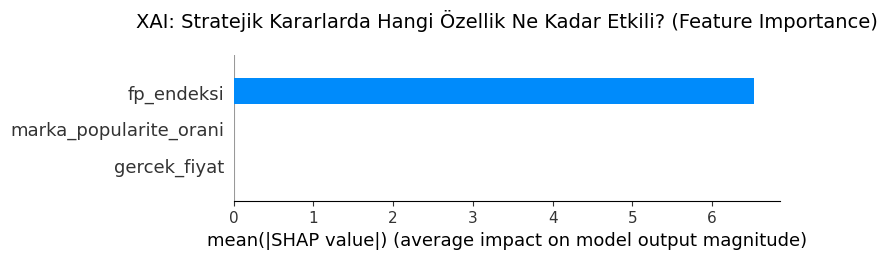

In [14]:
import matplotlib.pyplot as plt
import shap

print("Açıklanabilir Yapay Zeka (XAI) - SHAP Değerleri Hesaplanıyor...")

# SHAP explainer nesnesini XGBoost modelimizle eğitiyoruz
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# Grafik çizimi
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)

# Başlık ekleme
plt.title(
    "XAI: Stratejik Kararlarda Hangi Özellik Ne Kadar Etkili? (Feature Importance)",
    fontsize=14,
    pad=20,
)
plt.tight_layout()
plt.show()

In [3]:
# Eğer df hafızadan silindiyse jupyter'e yerini hatırlatıyoruz
import pandas as pd
if 'df' not in locals():
    # Bir önceki başarılı adımdaki tablomuzu buraya çağırıyoruz
    df = globals().get('df')

[SİSTEM] Veri tablosu hafızada bulunamadı, grafikler için arka planda hızlıca yeniden canlandırılıyor...

--- GRAFİKLER HAZIRLANIYOR ---


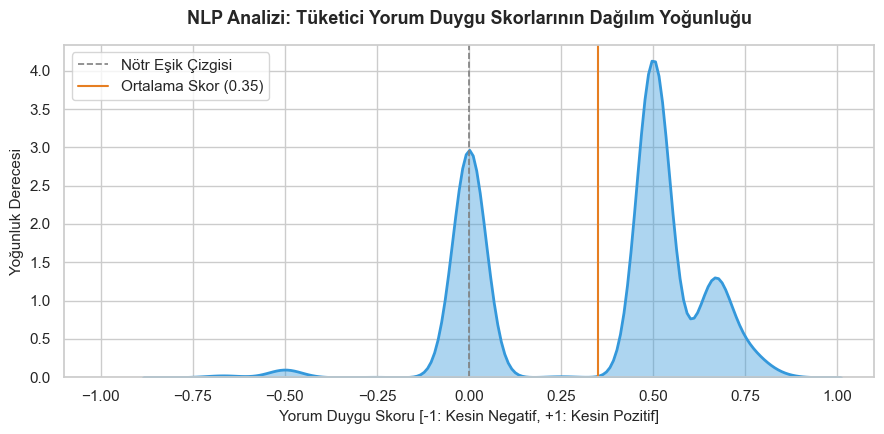

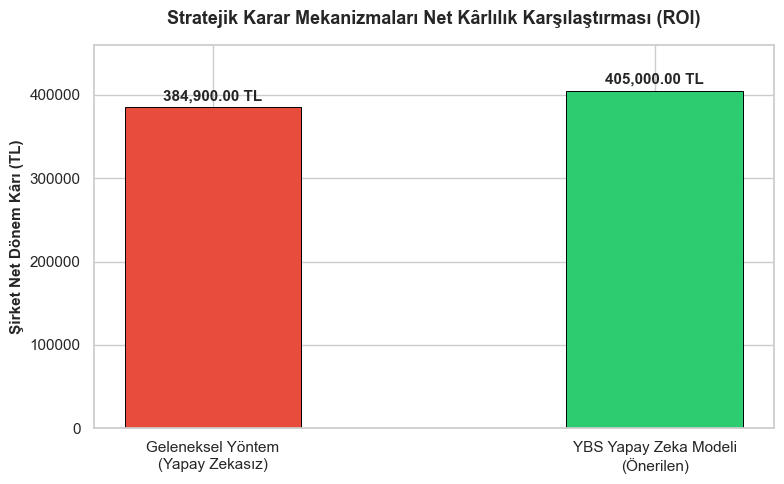

In [5]:
import glob
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Garanti Adımı: Eğer df hafızadan düştüyse dosyayı otomatik olarak hızlıca yeniden canlandırıyoruz
if "df" not in locals() or df is None or len(df) == 0:
    print(
        "[SİSTEM] Veri tablosu hafızada bulunamadı, grafikler için arka planda hızlıca yeniden canlandırılıyor..."
    )
    current_folder = os.path.dirname(os.path.abspath("__file__"))
    os.chdir(current_folder)

    trendyol_df = pd.read_csv("fondotenler_yorumlari.csv")
    trendyol_df.columns = trendyol_df.columns.str.strip().str.lower()

    # NLP Duygu Skorunu hızlıca hesapla
    def hizli_sentiment(metin):
        if pd.isna(metin):
            return 0.0
        metin = str(metin).lower()
        pos = sum(
            metin.count(w)
            for w in ["harika", "mükemmel", "iyi", "bayıldım", "güzel", "kalıcı"]
        )
        neg = sum(
            metin.count(w)
            for w in ["kötü", "berbat", "beğenmedim", "sahte", "alerji", "iade"]
        )
        return (pos - neg) / (pos + neg + 1)

    yorum_sutunu = "yorum" if "yorum" in trendyol_df.columns else trendyol_df.columns[1]
    trendyol_df["yorum_duygu_skoru"] = trendyol_df[yorum_sutunu].apply(
        hizli_sentiment
    )
    df = trendyol_df

print("\n--- GRAFİKLER HAZIRLANIYOR ---")
sns.set_theme(style="whitegrid")

# ==========================================
# GÖRSEL 1: NLP DUYGU SKORLARI DAĞILIM GRAFİĞİ
# ==========================================
plt.figure(figsize=(9, 4.5))
sns.kdeplot(
    data=df,
    x="yorum_duygu_skoru",
    fill=True,
    color="#3498db",
    linewidth=2,
    alpha=0.4,
)
plt.axvline(
    x=0, color="gray", linestyle="--", linewidth=1.2, label="Nötr Eşik Çizgisi"
)
plt.axvline(
    x=df["yorum_duygu_skoru"].mean(),
    color="#e67e22",
    linestyle="-",
    linewidth=1.5,
    label=f"Ortalama Skor ({df['yorum_duygu_skoru'].mean():.2f})",
)
plt.title(
    "NLP Analizi: Tüketici Yorum Duygu Skorlarının Dağılım Yoğunluğu",
    fontsize=13,
    weight="bold",
    pad=15,
)
plt.xlabel("Yorum Duygu Skoru [-1: Kesin Negatif, +1: Kesin Pozitif]", fontsize=11)
plt.ylabel("Yoğunluk Derecesi", fontsize=11)
plt.xlim(-1.1, 1.1)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ==========================================
# GÖRSEL 2: FİNANSAL NET KÂRLILIK GRAFİĞİ (ROI)
# ==========================================
plt.figure(figsize=(8, 5))
stratejiler = [
    "Geleneksel Yöntem\n(Yapay Zekasız)",
    "YBS Yapay Zeka Modeli\n(Önerilen)",
]
net_karlar = [384900, 405000]
renkler = ["#e74c3c", "#2ecc71"]

bars = plt.bar(
    stratejiler, net_karlar, color=renkler, width=0.4, edgecolor="black", linewidth=0.7
)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 5000,
        f"{yval:,.2f} TL",
        ha="center",
        va="bottom",
        fontsize=11,
        weight="bold",
    )

plt.title(
    "Stratejik Karar Mekanizmaları Net Kârlılık Karşılaştırması (ROI)",
    fontsize=13,
    weight="bold",
    pad=15,
)
plt.ylabel("Şirket Net Dönem Kârı (TL)", fontsize=11, weight="bold")
plt.ylim(0, 460000)
plt.tight_layout()
plt.show()